In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results, get_results_zero_latency

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_noremoval = get_results(
    f"results/data_runs_focused_noremoval.hdf",
    filter_times_before=times_before
)
results_varremoval = get_results(
    f"results/data_runs_focused_varied_removal.hdf",
    filter_times_before=times_before
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

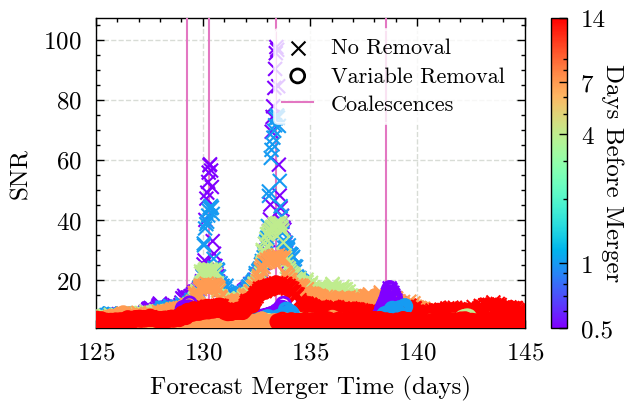

In [4]:
fig_focused_predict, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    results_two=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    label_two='Variable Removal',
    start_time_offset=125,
    end_time_offset=145,
    legend_loc='upper right'
)
# fig_focused_predict.savefig('plots/focused_results_prediction.pdf')


(3.0, 20.0)

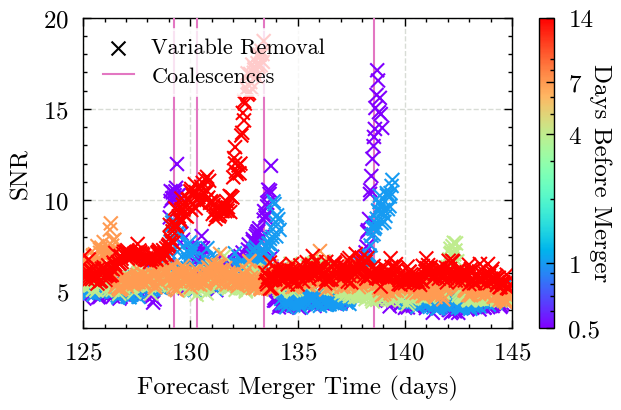

In [5]:
fig_focused_predict_varonly, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    start_time_offset=125,
    end_time_offset=145,
    legend_loc='upper left'
)
_[0].set_ylim(3,20)

# fig_focused_predict.savefig('plots/focused_results_prediction.pdf')

/local/gareth.cabourndavies/ipykernel_2848063/2331197504.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_focused_dataend.legend(loc='upper left')


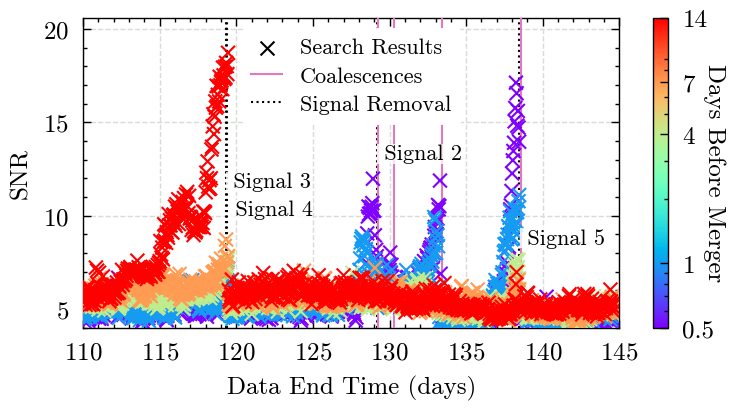

In [6]:
fig_focused_dataend, (ax_focused_dataend, labels, lines) = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Search Results',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
    width_factor=1.25
)
# Add lines for when the signals are removed from the data
lines.append(ax_focused_dataend.axvline(
    0,
    c='k',
    linestyle=':'
))
labels.append('Signal Removal')
ax_focused_dataend.legend(loc='upper left')
for signal_number, time_before in zip([2,3,4,5], [7200, 11*86400, 14*86400, 7200]):
    ax_focused_dataend.axvline(
        (truth_times_s[signal_number] - time_before) / 86400,
        c='k',
        linestyle=':'
    )
    ax_focused_dataend.text(
        (truth_times_s[signal_number] - time_before + 1800) / 86400,
        16-signal_number*1.5,
        f' Signal {signal_number}', 
        fontsize=8,
        zorder=40,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none',boxstyle='square,pad=0')
    )
leg = ax_focused_dataend.legend(
    handles=lines,
    labels=labels,
    loc='upper center',
    framealpha=1,
    frameon=True,
)
leg.set_zorder(50)
fig_focused_dataend.savefig(f'plots/focused_results_data_end_time.pdf')
fig_focused_dataend.savefig(f'{paper_plots_dir}/figure_X_focused_region_variable_removal.png')

/local/gareth.cabourndavies/ipykernel_2848063/4234388819.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow')
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/matplotlib/transforms.py:2036: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/matplotlib/transforms.py:2036: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
/home/gareth.cabourndavies/envir

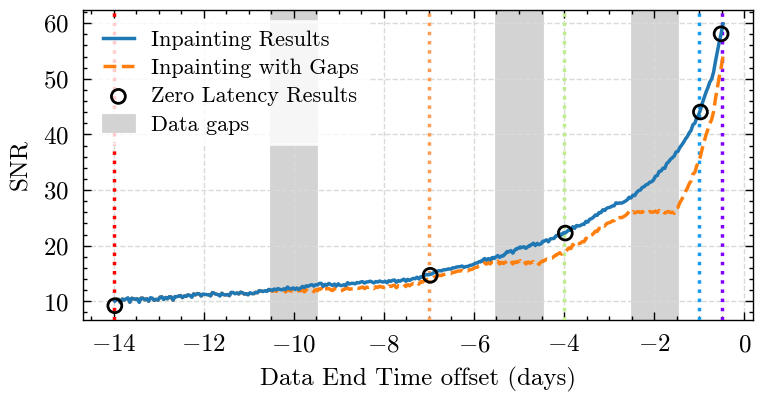

In [7]:
from matplotlib import cm
from matplotlib import colors as mcolors
import numpy as np


# For signal zero - plot the results filtered for the closest to the predicted merger time
example_signal = 0

# Get the zero-latency results for this signal
results_zero_latency = get_results_zero_latency(
    "../zero_latency/results/psd_estimate/data_runs_raw_{time_before}_results.hdf",
    times_before
)

results_estimate_all = get_results(
    f"results/data_runs_psd_estimate.hdf"
)

# Filter the zero latency results to only use the closest point for each

zl_results_data_end_time = []
zl_results_snr = []

for t_before in times_before:
    this_t = results_zero_latency['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_zero_latency['time'][this_t] - truth_times_s[example_signal])
    )
    zl_results_data_end_time.append(results_zero_latency['data_end_time'][this_t][closest_match])
    zl_results_snr.append(results_zero_latency['snr'][this_t][closest_match])

zl_results_data_end_time = np.array(zl_results_data_end_time)
zl_results_snr = np.array(zl_results_snr)

width = plt.rcParams["figure.figsize"][0] * 1.25
height = plt.rcParams["figure.figsize"][1]

fig, ax = plt.subplots(1, figsize=(width, height),)


ip_times_before = np.unique(results_estimate_all['time_before'])
ip_results_data_end_time = []
ip_results_snr = []
for t_before in ip_times_before:
    this_t = results_estimate_all['time_before'] == t_before
    closest_match = np.argmin(
        abs(results_estimate_all['time'][this_t] - truth_times_s[example_signal])
    )
    ip_results_data_end_time.append(results_estimate_all['data_end_time'][this_t][closest_match])
    ip_results_snr.append(results_estimate_all['snr'][this_t][closest_match])

inpainting_gaps_results = get_results(
    "results/data_runs_signal_0_gaps.hdf",
)
ipg_times_before = np.unique(inpainting_gaps_results['time_before'])
ipg_results_data_end_time = []
ipg_results_snr = []
for t_before in ip_times_before:
    this_t = inpainting_gaps_results['time_before'] == t_before
    closest_match = np.argmin(
        abs(inpainting_gaps_results['time'][this_t] - truth_times_s[example_signal])
    )
    ipg_results_data_end_time.append(inpainting_gaps_results['data_end_time'][this_t][closest_match])
    ipg_results_snr.append(inpainting_gaps_results['snr'][this_t][closest_match])


ax.plot(
    (ip_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ip_results_snr,
    linewidth=1.25,
    color='tab:blue',
    label='Inpainting Results',
    zorder=10
)
ax.plot(
    (ipg_results_data_end_time - truth_times_s[example_signal]) / 86400,
    ipg_results_snr,
    linewidth=1.25,
    color='tab:orange',
    linestyle='--',
    label='Inpainting with Gaps',
    zorder=8
)

ax.scatter(
    (zl_results_data_end_time - truth_times_s[example_signal]) / 86400,
    zl_results_snr,
    edgecolor='k',
    marker='o',
    facecolors='none',
    label='Zero Latency Results',
    zorder=20

)

norm = mcolors.LogNorm(vmin=min(times_before), vmax=max(times_before))
cmap = cm.get_cmap('rainbow')
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

for time_before in times_before:
    ax.axvline(
        -time_before,
        c=sm.to_rgba(time_before),
        linestyle=':',
        linewidth=1.25,
        zorder=5
    )

for gap in [(2.5, 1.5), (5.5, 4.5), (10.5, 9.5)]:
    ax.axvspan(-gap[0], -gap[1], color='lightgray', zorder=0)
ax.axvspan(-np.inf, -np.inf, color='lightgray', zorder=0, label='Data gaps')

ax.grid(zorder=0)
ax.legend(loc='upper left')
ax.set_ylabel('SNR')
ax.set_xlabel('Data End Time offset (days)')
fig.show()
fig.savefig(f'plots/signal_{example_signal}_end_timeline.pdf')
fig.savefig(f'{paper_plots_dir}/figure_X_signal_{example_signal}_timeline.png', dpi=300)